In [52]:
# Import
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics.pairwise import nan_euclidean_distances
from sklearn.utils.extmath import randomized_svd

from scipy.interpolate import PchipInterpolator

In [20]:
# Configuration
DATA_DIR = '../data/'
X_TRAIN_PATH       = DATA_DIR + "X_train.csv"
Y_TRAIN_PATH       = DATA_DIR + "y_train.csv"
X_TEST_PATH        = DATA_DIR + "X_test.csv"
OUTPUT_SAMPLE_PATH = DATA_DIR + "new_output_sample.csv"

---

# 1. Taille et structure des fichiers

**Structure commune à tous les fichiers**  
Tous les fichiers partagent le même exa temporel:
- **Période**: 9 janvier 2023 -> 31 janvier 2023 (**23 jours**)
- **Pas de temps: 30 minutes** -> 1057 points par courbe
- **Index**: colonne `Horodate` au format *datetime*

In [36]:
# Aperçu rapide sans tout charger en mémoire
X_train_peek = pd.read_csv(X_TRAIN_PATH, index_col=0, nrows=5)
y_train_peek = pd.read_csv(Y_TRAIN_PATH, index_col=0, nrows=5)
X_test_peek  = pd.read_csv(X_TEST_PATH,  index_col=0, nrows=5)
sample_peek  = pd.read_csv(OUTPUT_SAMPLE_PATH, index_col=0, nrows=5)
 
print(f"X_train  : {X_train_peek.shape[1]} colonnes")
print(f"y_train  : {y_train_peek.shape[1]} colonnes")
print(f"X_test   : {X_test_peek.shape[1]} colonnes")
print(f"output_sample : {sample_peek.shape[1]} colonnes")
 
print(f"\nIndex (timestamps) — exemples : {X_train_peek.index[:3].tolist()}")
print(f"Premières colonnes X_train : {X_train_peek.columns[:3].tolist()}")
print(f"Dernières colonnes X_train : {X_train_peek.columns[-3:].tolist()}")
print(f"\nColonnes y_train : {y_train_peek.columns[:3].tolist()} ... {y_train_peek.columns[-2:].tolist()}")


X_train  : 21000 colonnes
y_train  : 1000 colonnes
X_test   : 38140 colonnes
output_sample : 1000 colonnes

Index (timestamps) — exemples : ['2023-01-09 00:00:00', '2023-01-09 00:30:00', '2023-01-09 01:00:00']
Premières colonnes X_train : ['5423908671', '2568793410', '8310762594']
Dernières colonnes X_train : ['holed_998', 'holed_999', 'holed_1000']

Colonnes y_train : ['holed_1', 'holed_2', 'holed_3'] ... ['holed_999', 'holed_1000']


## 1.1 Chargement complet

In [37]:
print("Chargement X_train...")
X_train = pd.read_csv(X_TRAIN_PATH, index_col=0)
X_train.index = pd.to_datetime(X_train.index)
 
print("Chargement y_train...")
y_train = pd.read_csv(Y_TRAIN_PATH, index_col=0)
y_train.index = pd.to_datetime(y_train.index)
 
# Séparation courbes complètes / trouées
holed_cols    = [c for c in X_train.columns if c.startswith("holed_")]
complete_cols = [c for c in X_train.columns if not c.startswith("holed_")]
X_holed    = X_train[holed_cols]
X_complete = X_train[complete_cols]
 
print(f"\nX_train shape   : {X_train.shape}  ({X_train.shape[0]} timestamps × {X_train.shape[1]} courbes)")
print(f"  ├── courbes complètes : {len(complete_cols)}")
print(f"  └── courbes trouées  : {len(holed_cols)}")
print(f"y_train shape   : {y_train.shape}")

Chargement X_train...
Chargement y_train...

X_train shape   : (1057, 21000)  (1057 timestamps × 21000 courbes)
  ├── courbes complètes : 20000
  └── courbes trouées  : 1000
y_train shape   : (1057, 1000)


## 1.3. Analyse de timestamp

In [38]:
delta   = X_train.index[1] - X_train.index[0]
nb_days = (X_train.index[-1] - X_train.index[0]).days + 1
 
print(f"Début         : {X_train.index[0]}")
print(f"Fin           : {X_train.index[-1]}")
print(f"Nb de points  : {len(X_train.index)}")
print(f"Pas de temps  : {delta}  (30 minutes)")
print(f"Durée totale  : {nb_days} jours  ({nb_days/7:.1f} semaines)")

Début         : 2023-01-09 00:00:00
Fin           : 2023-01-31 00:00:00
Nb de points  : 1057
Pas de temps  : 0 days 00:30:00  (30 minutes)
Durée totale  : 23 jours  (3.3 semaines)


## 1.4. Statistique des valeurs de consommation

In [39]:
# Échantillon pour ne pas saturer la RAM
sample_vals = X_complete.iloc[:, :500].values.flatten()
sample_vals = sample_vals[~np.isnan(sample_vals)]
 
print(f"Min     : {sample_vals.min():.1f} W")
print(f"Max     : {sample_vals.max():.1f} W")
print(f"Moyenne : {sample_vals.mean():.1f} W")
print(f"Médiane : {np.median(sample_vals):.1f} W")
print(f"Std     : {sample_vals.std():.1f} W")
print(f"(calculé sur un échantillon de 500 courbes)")


Min     : 0.0 W
Max     : 5952.0 W
Moyenne : 361.4 W
Médiane : 181.0 W
Std     : 457.8 W
(calculé sur un échantillon de 500 courbes)


**Valeur de consommation** (sur les courbes complètes): 
- Min: `0 W`/ Max: `5952 W`/ Moyenne: `361 W`/ Médianne: `181 W`
- Distribution très asymétrique (médiane << moyenne -> beaucoup de faible consommations)

## 1.5. Analyse des trous (NaN)

In [40]:
nan_per_col = X_holed.isna().sum()
total_pts   = len(X_train.index)
 
print(f"Points totaux par courbe : {total_pts}")
print(f"\nNaN par courbe trouée :")
print(f"  Min     : {nan_per_col.min()} pts  ({nan_per_col.min()/total_pts*100:.1f}%)")
print(f"  Max     : {nan_per_col.max()} pts  ({nan_per_col.max()/total_pts*100:.1f}%)")
print(f"  Moyenne : {nan_per_col.mean():.1f} pts  ({nan_per_col.mean()/total_pts*100:.1f}%)")
print(f"  Médiane : {nan_per_col.median():.1f} pts  ({nan_per_col.median()/total_pts*100:.1f}%)")
print(f"\nCourbes avec au moins 1 trou : {(nan_per_col > 0).sum()}")
print(f"Courbes sans trou            : {(nan_per_col == 0).sum()}")

Points totaux par courbe : 1057

NaN par courbe trouée :
  Min     : 51 pts  (4.8%)
  Max     : 1056 pts  (99.9%)
  Moyenne : 129.9 pts  (12.3%)
  Médiane : 124.0 pts  (11.7%)

Courbes avec au moins 1 trou : 1000
Courbes sans trou            : 0


## 1.6. Structure des blocs de Nan (trous consécutifs)

In [41]:
gap_lengths = []
for col in holed_cols:
    series    = X_holed[col]
    is_nan    = series.isna()
    gap_start = None
    for i, v in enumerate(is_nan):
        if v and gap_start is None:
            gap_start = i
        elif not v and gap_start is not None:
            gap_lengths.append(i - gap_start)
            gap_start = None
    if gap_start is not None:
        gap_lengths.append(len(series) - gap_start)
 
gap_lengths = np.array(gap_lengths)
 
print(f"Nombre total de blocs de NaN : {len(gap_lengths)}")
print(f"\nTaille des blocs (en pas de 30 min) :")
print(f"  Min     : {gap_lengths.min()} pts  ({gap_lengths.min()*0.5:.1f}h)")
print(f"  Max     : {gap_lengths.max()} pts  ({gap_lengths.max()*0.5:.1f}h)")
print(f"  Moyenne : {gap_lengths.mean():.1f} pts  ({gap_lengths.mean()*0.5:.1f}h)")
print(f"  Médiane : {np.median(gap_lengths):.0f} pts  ({np.median(gap_lengths)*0.5:.1f}h)")
 
bins   = [1, 2, 4, 8, 16, 48, 96, 200, 10000]
labels = [
    "1 pt (30 min)",
    "2-3 pts (1-1.5h)",
    "4-7 pts (2-3.5h)",
    "8-15 pts (4-7.5h)",
    "16-47 pts (<1 jour)",
    "48-95 pts (~1 jour)",
    "96-199 pts (2-4 jours)",
    "200+ pts (>4 jours)",
]
 
print(f"\nDistribution des tailles de trous :")
for i, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
    count = ((gap_lengths >= lo) & (gap_lengths < hi)).sum()
    pct   = count / len(gap_lengths) * 100
    bar   = "●" * int(pct / 2)
    print(f"  {labels[i]:25s} : {count:5d} blocs ({pct:5.1f}%)  {bar}")


Nombre total de blocs de NaN : 55966

Taille des blocs (en pas de 30 min) :
  Min     : 1 pts  (0.5h)
  Max     : 857 pts  (428.5h)
  Moyenne : 2.3 pts  (1.2h)
  Médiane : 1 pts  (0.5h)

Distribution des tailles de trous :
  1 pt (30 min)             : 42031 blocs ( 75.1%)  ●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●
  2-3 pts (1-1.5h)          : 11436 blocs ( 20.4%)  ●●●●●●●●●●
  4-7 pts (2-3.5h)          :   249 blocs (  0.4%)  
  8-15 pts (4-7.5h)         :  1208 blocs (  2.2%)  ●
  16-47 pts (<1 jour)       :     9 blocs (  0.0%)  
  48-95 pts (~1 jour)       :   990 blocs (  1.8%)  
  96-199 pts (2-4 jours)    :    42 blocs (  0.1%)  
  200+ pts (>4 jours)       :     1 blocs (  0.0%)  


## 1.7. Analyse du fichier `X_test`

In [42]:
X_test_peek   = pd.read_csv(X_TEST_PATH, index_col=0, nrows=1)
holed_test    = [c for c in X_test_peek.columns if c.startswith("holed_")]
complete_test = [c for c in X_test_peek.columns if not c.startswith("holed_")]
 
print(f"X_test shape         : (1057, {X_test_peek.shape[1]})")
print(f"  ├── courbes complètes : {len(complete_test)}")
print(f"  └── courbes trouées  : {len(holed_test)}")

X_test shape         : (1057, 38140)
  ├── courbes complètes : 37140
  └── courbes trouées  : 1000


## 1.8. Format de soumission (`new_output_sample`)

In [43]:
sample = pd.read_csv(OUTPUT_SAMPLE_PATH, index_col=0)
sample.index = pd.to_datetime(sample.index)

print(f"Shape          : {sample.shape}")
print(f"NaN présents   : {sample.isna().sum().sum()}  (doit être 0 à la soumission)")
print(f"Colonnes       : {sample.columns[:3].tolist()} ... {sample.columns[-2:].tolist()}")
print(f"\nAperçu :")
print(sample.iloc[:3, :4].to_string())


Shape          : (1057, 1000)
NaN présents   : 0  (doit être 0 à la soumission)
Colonnes       : ['holed_1', 'holed_2', 'holed_3'] ... ['holed_999', 'holed_1000']

Aperçu :
                     holed_1  holed_2  holed_3  holed_4
Horodate                                               
2023-01-09 00:00:00     77.6   1172.0   5734.1    794.8
2023-01-09 00:30:00   4305.9   5845.4   4466.9   3266.4
2023-01-09 01:00:00   3014.1   1305.1   5737.4   1987.7


## 1.9. Visualisation

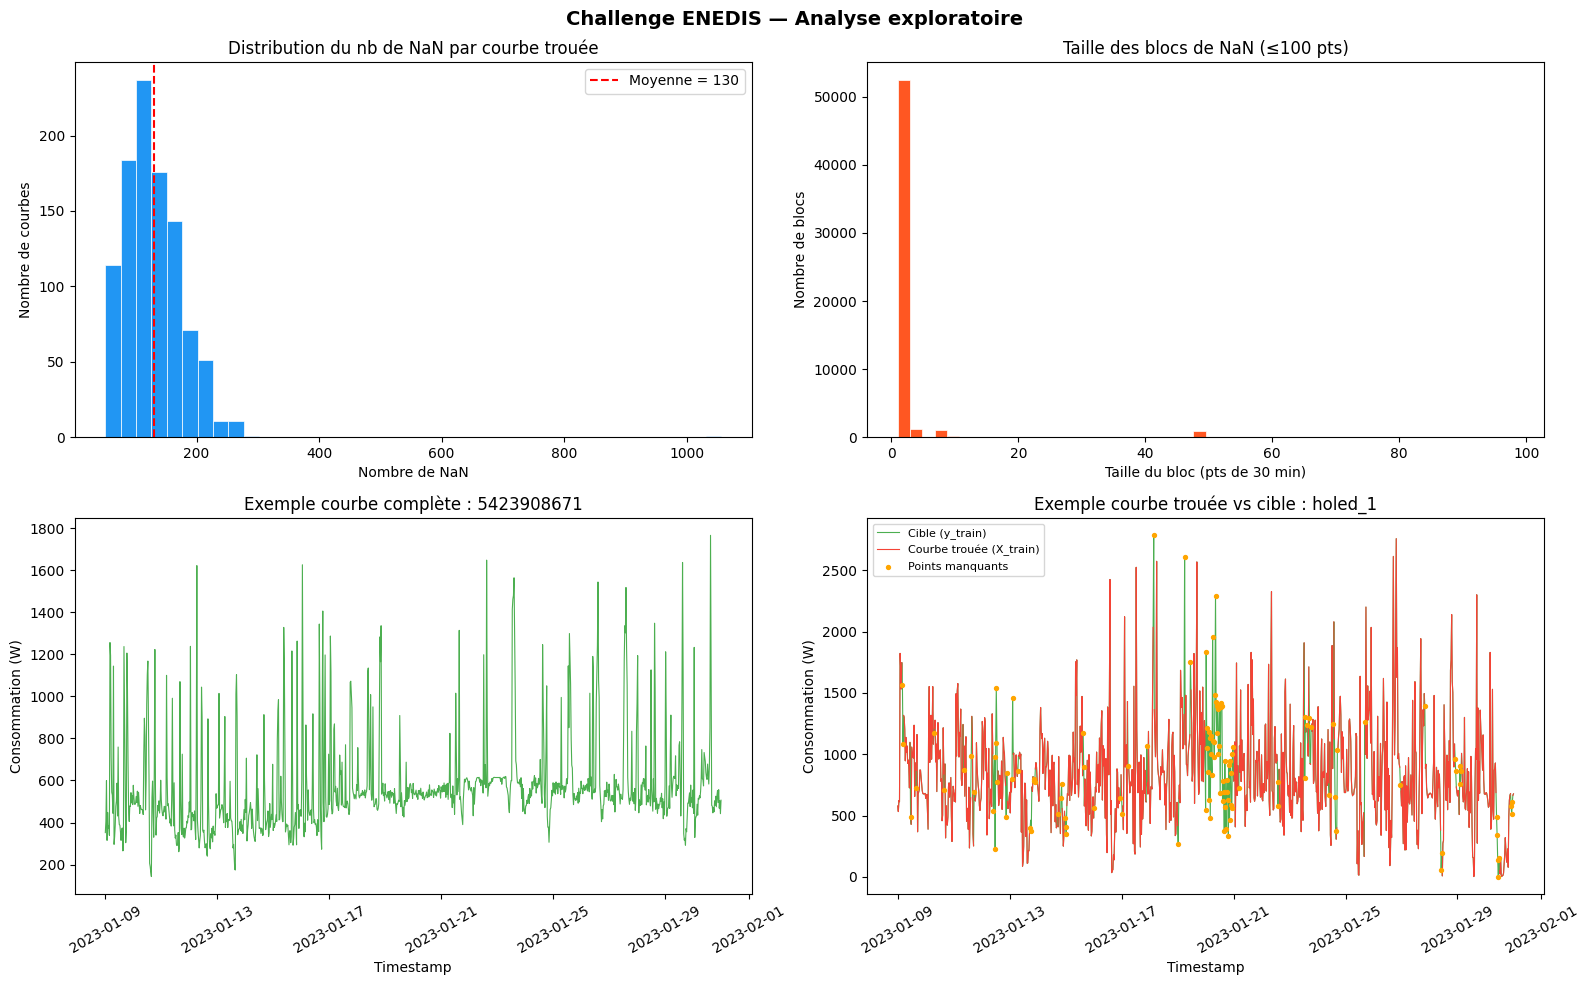

Figure sauvegardée : ../img/analyse_enedis.png


In [45]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Challenge ENEDIS — Analyse exploratoire", fontsize=14, fontweight="bold")

# --- 9a. Distribution du nb de NaN par courbe ---
ax = axes[0, 0]
ax.hist(nan_per_col.values, bins=40, color="#2196F3", edgecolor="white", linewidth=0.5)
ax.set_title("Distribution du nb de NaN par courbe trouée")
ax.set_xlabel("Nombre de NaN")
ax.set_ylabel("Nombre de courbes")
ax.axvline(nan_per_col.mean(), color="red", linestyle="--", label=f"Moyenne = {nan_per_col.mean():.0f}")
ax.legend()

# --- 9b. Distribution de la taille des blocs de NaN ---
ax = axes[0, 1]
ax.hist(gap_lengths[gap_lengths <= 100], bins=50, color="#FF5722", edgecolor="white", linewidth=0.5)
ax.set_title("Taille des blocs de NaN (≤100 pts)")
ax.set_xlabel("Taille du bloc (pts de 30 min)")
ax.set_ylabel("Nombre de blocs")

# --- 9c. Exemple de courbe complète ---
ax = axes[1, 0]
example_complete = X_complete.iloc[:, 0]
ax.plot(X_train.index, example_complete.values, color="#4CAF50", linewidth=0.8)
ax.set_title(f"Exemple courbe complète : {X_complete.columns[0]}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Consommation (W)")
ax.tick_params(axis="x", rotation=30)

# --- 9d. Exemple de courbe trouée vs cible ---
ax = axes[1, 1]
col_ex = holed_cols[0]
ax.plot(X_train.index, y_train[col_ex].values, color="#4CAF50", linewidth=0.8, label="Cible (y_train)", zorder=1)
ax.plot(X_train.index, X_holed[col_ex].values, color="#F44336", linewidth=0.8,
        label="Courbe trouée (X_train)", zorder=2)
nan_mask = X_holed[col_ex].isna()
ax.scatter(X_train.index[nan_mask], y_train[col_ex][nan_mask].values,
           color="orange", s=8, zorder=3, label="Points manquants")
ax.set_title(f"Exemple courbe trouée vs cible : {col_ex}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Consommation (W)")
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../img/analyse_enedis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : ../img/analyse_enedis.png")

---

# 2. Réflexion et suggestion de méthodes

Pour résumer les points clés de nos analyses précédentes: 
- **95% des trous font ≤ 3 points** (≤ 1h30) -> très faciles à imputer
- **~1000 blocs de 8 à 95 points** (~4h à 2 jours) -> là où se jouera vraiment le score MAE 
- **20000 courbes complètes disponibles comme référence** -> ressources énorme à exploter
- **Pas de temporalité longue**: seulement 23 jours, donc pas de saisonnalité annuelle

## 2.1. Méthode 1: Interpolation (baseline améliorée)

### 2.1.1. Qu'est ce que l'interpolation ?
L'interpolation consiste à estimer des valeurs dans la gamme des données existantes. Il est basé sur le principe selon lequel les points de cheminement peuvent être prédits avec précision à l'aide d'informations connues. 

> source: [geeksforgeeks.com](https://www.geeksforgeeks.org/data-analysis/what-is-data-interpolation/)

Dans notre cas, pour un trou entre deux points connus A (à gauche) et B (à droite), on estime les valeurs manquantes en traçant une courbe entre A et B. Selon le degré de la courbe:  
- Linéaire -> segement droit entre A et B
- Spline -> courbe lisse qui respecte aussi la dérivée en A et B
- PCHIP (*Piecewise Cubic Hermite Interpolating Polynomial*) -> courbe monotone qui ne "rebondit" pas entre A et B


### 2.1.2. Pourquoi c'est pertinent ici

Pour les **trous de 1-3 points** (75% des cas), la consommation varie peu sur 30-90min.  
L'interpolation est quasi-parfaite et imbattable en vitesse.

### 2.1.3. Limites

Dis comme ça on pourrait penser que c'est la méthode parfaite, sauf qu'on a remarqué précédemment ([Introduction de la partie 2](#2-réflexion-et-suggestion-de-méthodes)) qu'il existe des plages dans lesquel se situe des trous longs de plus d'une journée. Dans ce cas cette méthode ne pourra pas deviner un pic de consommation du soir. Elle tracera juste une droite ou une bourbe entre les bords du trou...

In [ ]:
def impute_interpolation(series, method='pchip'):
    """
    Impute les NaN d'une série temporelle par interpolation.
    method : 'linear', 'spline', 'pchip'
    """
    s = series.copy()

    if method == 'linear':
        s = s.interpolate(method='linear', limit_direction='both')

    elif method == 'spline':
        s = s.interpolate(method='spline', order=3, limit_direction='both')

    elif method == 'pchip':
        # PCHIP : monotone, évite les oscillations
        known_idx = np.where(~np.isnan(s.values))[0]
        known_val = s.values[known_idx]
        interp = PchipInterpolator(known_idx, known_val, extrapolate=True)
        nan_idx = np.where(np.isnan(s.values))[0]
        s.iloc[nan_idx] = interp(nan_idx)

    return s

---

## 2.2. Méthode 2: Moyenne saisonnière (profil journalier)

### 2.2.1. Qu'est ce que c'est ?
L'idée générale est la suivante: "*La consommation future ressemble à la consommation observée dans les situations similaires du passé.*".

La consommation électrique est **fortement périodique**: à 8h du matin, on consomme à peu près la même chose chaque jour. On peut donc imputer un point manquant à l'heure `h` du jour `d` par la moyenne de tous les points connus à la même heure `h` dans la même courbe.

> On se rapproche énormément du principe de *pattern matching*

> [Github](https://github.com/welch/seasonal) interprétant très bien la puissance du modèle.

### 2.2.1. Principe du profil journalier

On construit un **profil type** à partir des historiques.  
Par exemple, si les données sont mesurées toutes les heures:
| Heure | Conso. Moyenne |
|-|-|
| 00h | 1,2kWh |
| 01h | 1,0kWh |
| 08h | 3,8kWh |
| 19h | 5,1kWh |

**Le modèle dit alors:** "*À 19h, ce client consomme en moyenne 5.1 kWh.*"  
Donc pour prédire la consommation à un instant $t$, on prend simplement la moyenne historique des consommations observées au même moment.


### 2.2.2. Version "moyenne saisonnière"
La version saisonnière ajoute des regroupements plus intelligents :

- même heure,
- même jour de semaine,
- même saison,
- éventuellement même type de journée.
- etc.

| Condition             | Moyenne |
|-|-|
| Lundi à 18h en hiver  | 6.2 kWh |
| Samedi à 18h en hiver | 4.7 kWh |
| Lundi à 18h en été    | 2.9 kWh |

La prédiction devient alors :
$$
\hat{y}(t) = \text{moyenne des consommations similaires}
$$

### 2.2.3. Pourquoi c'est pertinent ici ?
Comparé à la [méthode précedente](#21-méthode-1-interpolation-baseline-améliorée), celle-ci est bien plus efficace pour les **trous de 1 journée complète** (bloc de 48 points), car l'interpolation ne peut rien faire mais le profil moyen de la courbe est très informatif.  
La consommation électrique est souvent très répétitive et fortement périodique, donc un simple profil moyen peut déjà donner des résultats étonnamment bons.

### 2.2.4. Quelles sont les limites ?
Si la courbe a beaucoup de trous, le profil moyen sera peu fiable. Et cette méthode ignore les voisins temporels immédiats.
De plus, celle-ci ne capture pas les anomalies comme par exemple les vacances, jours fériés, pannes etc.

In [48]:
def impute_seasonal(series, period=48):
    """
    Impute les NaN par la moyenne des valeurs à la même position
    dans le cycle journalier (period=48 pour pas de 30 min).
    """
    s = series.copy()
    values = s.values.copy()
    n = len(values)

    # Calcul de la moyenne par position dans le cycle
    profile = np.full(period, np.nan)
    for p in range(period):
        positions = np.arange(p, n, period)
        known = values[positions][~np.isnan(values[positions])]
        if len(known) > 0:
            profile[p] = known.mean()

    # Imputation des NaN avec le profil
    for i in range(n):
        if np.isnan(values[i]):
            values[i] = profile[i % period]

    s[:] = values
    return s

---

## 2.3. Méthode 3: k-NN sur les parties observées

### 2.3.1. Tout d'abord, qu'est ce que k-NN ?
Le **k-NN** (*k-Nearest Neighbors*, ou **k plus proches voisins**) est une méthode très intuitive.  
L'idée générale est: "*Si des situations passées ressemblent à la situation actuelle, alors leur résultat futur devrait aussi se ressembler.*"  

Dans le cas de notre dataset, le modèle:
1. Calcule la distance avec toutes les courbes complètes, **uniquement sur les timestamps disponibles** (en ignorant les NaN)
2. Sélectionne les $k$ courbes les plus proches
3. Impute les valeurs manquantes par la **moyenne pondérée** des valeurs des voisines à ces même timestamps.

> Le paramètre $k$ désigne le **nombre de voisins utilisés.**

Prennons un exemple avec notre dataset:
| | | | | | | |
|-|-|-|-|-|-|-|
| Courbe trouée   |   1200W   |    ???   |    ???    |    800W   |    ???    |    600W   |
| Voisine 1       |   1180W   |   950W   |    870W   |    820W   |    650W   |    590W   |
| Voisine 2       |   1250W   |   980W   |    900W   |    790W   |    700W   |    610W   |
| **Imputation**  |           | **965W** | **885W**  |           |  **675W** |           |

Le k-NN cherche alors dans l'historique les **journées ayant des caractéristiques proches.**

Sans trop rentrer dans les détails (et éviter de se faire mal à la tête), on peut utiliser la **distance euclidienne** pour définir les valeurs le plus proches de notre point d'origine: 
$$
d(x,y) = \sqrt{\sum_i{(x_i - y_i)^2}}
$$

**Plus la distance est petite, plus les situations sont considérées similaires.**

> sources: 
> - [Wikipedia](https://fr.wikipedia.org/wiki/M%C3%A9thode_des_k_plus_proches_voisins)
> - [IBM](https://www.ibm.com/fr-fr/think/topics/knn)
> - [geeksforgeeks](https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/) (avec une très bonne explication visuelle)


### 2.3.2. Pourquoi c'est pertinent ici

Très idéal pour les **trous longs** où l'interpolation échoue. Si la courbe ressemble à un profil "famille avec enfants", les voisines auront aussi un pic le soir, et l'impulsion sera réaliste.


### 2.3.3. Quelles sont les limites ?
Coûteux en calcul (distance à 20000 courbes). Il faut **normaliser** les courbes avant de calculer les distances, sinon une courbe à 5000W écrasera une courbe à 200W.

In [50]:
def impute_knn(holed_series, reference_df, k=5):
    """
    Impute les NaN d'une courbe par k-NN sur les courbes de référence.
    
    holed_series  : pd.Series avec NaN (courbe à compléter)
    reference_df  : pd.DataFrame des courbes complètes (colonnes = courbes)
    k             : nombre de voisins
    """
    target = holed_series.values.reshape(1, -1)         # (1, T)
    refs   = reference_df.values.T                       # (N, T)

    # Normalisation par courbe (z-score) pour comparer des profils
    def zscore(x):
        std = np.nanstd(x)
        return (x - np.nanmean(x)) / std if std > 0 else x - np.nanmean(x)

    target_norm = zscore(target[0]).reshape(1, -1)
    refs_norm   = np.array([zscore(r) for r in refs])

    # Distance sur les timestamps communs (ignore NaN)
    dists = nan_euclidean_distances(target_norm, refs_norm)[0]  # (N,)

    # Sélection des k plus proches voisins
    knn_idx     = np.argsort(dists)[:k]
    knn_weights = 1.0 / (dists[knn_idx] + 1e-8)
    knn_weights /= knn_weights.sum()

    # Imputation pondérée
    result = holed_series.copy()
    nan_mask = np.isnan(result.values)
    if nan_mask.any():
        knn_values = refs[knn_idx][:, nan_mask]          # (k, nb_NaN)
        imputed    = np.average(knn_values, axis=0, weights=knn_weights)
        result.values[nan_mask] = imputed

    return result

---

## 2.4. Méthode 4: Matrix Factorization (SVD)

### 2.4.1. Qu'est ce que c'est ?
La **Matrix Factorization** (factorisation de matrice), et plus particulièrement la **SVD** (Singular Value Decomposition), est une méthode beaucoup plus mathématique que celles d'avant.  

On considère la matrice $M$ de la forme $(\text{timestamp} \times \text{courbes})$ où les 1000 colonnes trouées ont des NaN. L'idée est que cette matrice est de **rang faible**: il existe seulement quelques "profils de consommation" fondamentaux (nuit/jour, semaine/week-end, faible/fort consommateur), et chaque courbe est une combinaison de ces profils.  

La SVD décompose $M \approx U \times \Sigma \times V^T$ 

où: 
- $M$ = matrice originale,
- $U$ = profils des lignes,
- $\Sigma$ = importance des composantes,
- $V^T$ = profils des colonnes.

Elle permet de reconstruire les valeurs manquantes par des itérations successives: 

- Itération 1 : remplir les NaN par la moyenne de la colonne
- Itération 2 : faire la SVD tronquée -> reconstruire M -> mettre à jour les NaN
- Itération 3 : refaire la SVD -> converger vers une solution stable 

Prennons un exemple, on part d'une grand matrice de données: 
| Client | 00h | 01h | 02h | ... |
| ------ | --- | --- | --- | --- |
| A      | 1.2 | 1.0 | 0.9 | ... |
| B      | 2.1 | 2.0 | 1.8 | ... |
| C      | 0.7 | 0.6 | 0.5 | ... |

Cette matrice contient: beaucoup de redondance, des comportements similaires, des motifs cachés...  
La factorisation charche à dire: "*Cette énorme matrice peut être approximée par quelques comportements fondamentaux.*"

Imaginons maintenant que:
- certains clients ont un profil "travail de bureau",
- d'autres "présence à domicile",
- d'autres "chauffage électrique".

La SVD essaie automatiquement de **découvrir ces profils cachés** et **comment chaque clients les combine.**

> Sources:
> - [geeksforgeeks](https://www.geeksforgeeks.org/data-science/singular-value-decomposition-svd/)
> - [youtube](https://www.youtube.com/watch?v=vSczTbgc8Rc) (visualisation du concept, très intéressant)

### 2.4.2. Pourquoi c'est pertinent ici

On exploite la **structure globale** de toutes les courbes simultanément. C'est très bien quand les courbes ont des patterns communs, ce qui est le cas ici ! (courbes synthétiques générées par le même modèle).

De plus, SVD compresse l'information. Au lieu de stocker des milleirs de colonnes, on garde seulement quelques "facteurs latents", par exemple:
- facteur 1 = activité journalière,
- facteur 2 = chauffage,
- facteur 3 = week-end.

Ces facteurs ne sont pas données explicitements, **la méthode les découvre seule**.

### 2.4.3. Quelles sont les limites ?
Malheureusement les interprétations sont parfois difficile, les facteurs latents ne sont pas toujours explicites (humainemment parlant).  
De plus, SVD est **sensible au choix du rang de troncature**, cela signifie que garder trop peu ou trop de composantes peut fortement dégrader les résultats. Par exemple, SVD peut conserver seulement le cycle jour/nuit mais perdre les week-ends, les habitudes particulières etc. Ce qui rend la reconstruction mauvaise.  
Tout ses petits détails rend SVD plus lent que le k-NN pour de petits trous.

In [53]:
def impute_svd(matrix, rank=20, n_iter=10):
    """
    Imputation par SVD tronquée itérative (IterativeSVD).
    
    matrix : np.ndarray (timestamps × courbes), avec NaN
    rank   : nombre de composantes latentes à conserver
    n_iter : nombre d'itérations
    """
    M = matrix.copy()
    nan_mask = np.isnan(M)

    # Initialisation : remplir les NaN par la moyenne de chaque colonne
    col_means = np.nanmean(M, axis=0)
    M[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

    for iteration in range(n_iter):
        # SVD tronquée
        U, sigma, Vt = randomized_svd(M, n_components=rank, random_state=42)
        # Reconstruction basse dimension
        M_reconstructed = U @ np.diag(sigma) @ Vt
        # Mise à jour uniquement des positions NaN
        M[nan_mask] = M_reconstructed[nan_mask]

        print(f"  Itération {iteration+1}/{n_iter} terminée")

    return M

## 2.5. Méthode 5: Stratégie hybride

### 2.5.1. Principe

Les méthodes précédentes ne se valent pas selon la taille du trou. L'idée est de combiner automatiquement selon le contexte:

| Type de trou | Méthode | Atouts |
|-|-|-|
| 1-3 pts  | PCHIP                      | rapide, précis, contexte immédiat suffisant |
| 4-47 pts | k-NN pondéré               | besoin des voisins pour un profil réaliste  |
| 48+ pts  | SVD ou moyenne saisonnière | trou trop long pour interpoler              |

### 2.5.2. Pourquoi c'est le meilleur choix dans notre cas ?

Chaque méthode est optimal dans sa plage. En combinant, on ne sacrifie rien sur les petits trous (qui sont 95% des cas) tout en traitant correctement les trous longs (qui concentrent l'erreur MAE)

In [54]:
def impute_hybrid(holed_series, reference_df, 
                  threshold_short=3, threshold_medium=47):
    """
    Stratégie hybride selon la taille des blocs de NaN.
    
    threshold_short  : blocs <= cette taille → interpolation PCHIP
    threshold_medium : blocs <= cette taille → k-NN
    au-delà          → moyenne saisonnière
    """
    result = holed_series.copy()
    values = result.values.copy()
    n = len(values)

    # Détecter les blocs de NaN
    gaps = []
    i = 0
    while i < n:
        if np.isnan(values[i]):
            start = i
            while i < n and np.isnan(values[i]):
                i += 1
            gaps.append((start, i - 1))  # (début, fin inclus)
        else:
            i += 1

    for (start, end) in gaps:
        size = end - start + 1

        if size <= threshold_short:
            # --- PCHIP : interpolation locale ---
            result = impute_interpolation(result, method='pchip')

        elif size <= threshold_medium:
            # --- k-NN : courbes voisines ---
            result = impute_knn(result, reference_df, k=5)

        else:
            # --- Saisonnière : profil journalier ---
            result = impute_seasonal(result, period=48)

    return result

---